# Explainable AI Email Triage: Week 6 Testing and Debugging

This experiment log evaluates the frozen Week 4 email-triage candidate without changing the submitted Week 3 or Week 4 notebooks. Week 6 uses cross-validation because this project has labeled historical data but no deployed system, live traffic, or safe treatment-and-control environment for an A/B test.

**Checkpoint 2 status:** Complete. This version retains the validated starting population and preserved split, then runs the preregistered nested cross-validation and threshold workflow using only the 159-message training partition. The 40-message holdout remains sealed and unscored.

## tl;dr

Checkpoint 2 tested the frozen Week 4 candidate with nested stratified cross-validation on the 159-message training partition. The preregistered rule selected `0.45` in every outer fold and in the full-training out-of-fold analysis. Compared with `0.50`, it raised urgent recall from 8.3% to 100% and urgent F1 from 0.154 to 0.262, so it passed the formal reliability rule. However, it also labeled all 159 outer-fold validation messages urgent, producing 135 false positives, 15.1% precision, and 15.1% accuracy. I therefore freeze `0.45` for the later preregistered holdout comparison, but I do not treat it as operationally acceptable. The result identifies weak probability separation and excessive review burden as the main debugging findings. The 40-message holdout remains sealed, and no raw email text appears in notebook outputs or exported evidence.

## Context and methods

The Week 6 assignment requires updated code with test results and a 2–3-page debugging and evaluation report. The testing workflow will use the frozen Week 4 candidate, nested stratified cross-validation, a preregistered probability-threshold grid, privacy-safe error analysis, and one preliminary holdout comparison after every training-data decision is locked.

The inner folds will select the probability threshold. The outer folds will evaluate that selection process on observations the inner loop did not use. This separation follows scikit-learn's guidance on [nested cross-validation](https://scikit-learn.org/stable/auto_examples/model_selection/plot_nested_cross_validation_iris.html). The notebook will emphasize urgent recall, urgent F1, urgent false negatives, and false-positive review burden rather than accuracy alone.

### Key assumptions and boundaries

- The reviewed label manifest is the label source of truth.
- The Week 4 candidate remains frozen; Week 6 will not reopen broad hyperparameter tuning.
- All threshold selection will remain inside the 159-message training partition.
- The 40-message holdout is preliminary comparison evidence because earlier project work already used it.
- The model remains decision support for a person. No result in this notebook approves autonomous email handling.
- Privacy-safe outputs may contain identifiers, labels, probabilities, error types, approved categories, and aggregate metrics. They must not contain subjects, bodies, excerpts, reviewer notes, or unnecessary personal information.

## Setup and reproducibility

The setup cells record the environment and freeze every parameter needed for the later testing workflow before loading the data.

In [1]:
# I record the analysis environment before loading project data.
import gc
import hashlib
import json
import re
import sys
import time
from datetime import datetime, timezone
from email import policy
from email.parser import Parser
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    train_test_split,
)
from sklearn.pipeline import Pipeline

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)

Python: 3.11.8
NumPy: 2.4.6
pandas: 3.0.3
scikit-learn: 1.9.0


In [2]:
# I freeze the Week 6 configuration before running any model evaluation.
SEED = 42
TEST_SIZE = 0.20
OUTER_FOLDS = 5
INNER_FOLDS = 4
THRESHOLDS = (0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50)
LABEL_ORDER = ("nonurgent", "urgent")

EXPECTED_RECORDS = 199
EXPECTED_LABEL_COUNTS = {"nonurgent": 169, "urgent": 30}
EXPECTED_TRAIN_RECORDS = 159
EXPECTED_HOLDOUT_RECORDS = 40
EXPECTED_TRAIN_LABEL_COUNTS = {"nonurgent": 135, "urgent": 24}
EXPECTED_HOLDOUT_LABEL_COUNTS = {"nonurgent": 34, "urgent": 6}

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA = PROJECT_ROOT / "data" / "raw" / "emails.csv"
LABEL_MANIFEST = PROJECT_ROOT / "data" / "labels" / "enron_urgency_labels_v1.csv"
METRICS_DIR = PROJECT_ROOT / "results" / "metrics"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
METRICS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

missing_inputs = [path for path in (RAW_DATA, LABEL_MANIFEST) if not path.exists()]
if missing_inputs:
    raise FileNotFoundError(
        "Missing required input(s): " + ", ".join(str(path) for path in missing_inputs)
    )

label_manifest_sha256 = hashlib.sha256(LABEL_MANIFEST.read_bytes()).hexdigest()
input_inventory = pd.DataFrame(
    [
        {
            "input": "Raw Enron source",
            "path": str(RAW_DATA.relative_to(PROJECT_ROOT)),
            "bytes": RAW_DATA.stat().st_size,
            "sha256": "Not calculated for the 1.4 GB local source",
        },
        {
            "input": "Reviewed label manifest",
            "path": str(LABEL_MANIFEST.relative_to(PROJECT_ROOT)),
            "bytes": LABEL_MANIFEST.stat().st_size,
            "sha256": label_manifest_sha256,
        },
    ]
)
display(input_inventory)

,input,path,bytes,sha256
0,Raw Enron source,data/raw/emails.csv,1426122219,Not calculated for the 1.4 GB local source
1,Reviewed label manifest,data/labels/enron_urgency_labels_v1.csv,13038,1d97ae4369cfe86cd53e34f97e5d3ebc74c6f03e5fb485...


### Freeze the Week 4 candidate

The candidate combines unigram TF-IDF with class-balanced logistic regression. I retain `C=0.1`, `min_df=2`, sublinear term frequency, and the fixed random state. This checkpoint constructs and verifies the pipeline but does not fit it.

In [3]:
# I construct the frozen candidate exactly as preregistered for Week 6.
def make_frozen_candidate():
    return Pipeline(
        [
            (
                "tfidf",
                TfidfVectorizer(
                    lowercase=True,
                    stop_words="english",
                    ngram_range=(1, 1),
                    min_df=2,
                    sublinear_tf=True,
                ),
            ),
            (
                "classifier",
                LogisticRegression(
                    C=0.1,
                    class_weight="balanced",
                    max_iter=1_000,
                    random_state=SEED,
                ),
            ),
        ]
    )


frozen_candidate = make_frozen_candidate()
parameters = frozen_candidate.get_params()
expected_parameters = {
    "tfidf__lowercase": True,
    "tfidf__stop_words": "english",
    "tfidf__ngram_range": (1, 1),
    "tfidf__min_df": 2,
    "tfidf__sublinear_tf": True,
    "classifier__C": 0.1,
    "classifier__class_weight": "balanced",
    "classifier__max_iter": 1_000,
    "classifier__random_state": SEED,
}
for parameter, expected_value in expected_parameters.items():
    assert parameters[parameter] == expected_value, f"Unexpected value for {parameter}."

candidate_configuration = pd.DataFrame(
    [{"parameter": key, "frozen_value": repr(value)} for key, value in expected_parameters.items()]
)
display(candidate_configuration)
print("Frozen candidate configuration: verified; model not fitted in Checkpoint 1.")

,parameter,frozen_value
0,tfidf__lowercase,True
1,tfidf__stop_words,'english'
2,tfidf__ngram_range,"(1, 1)"
3,tfidf__min_df,2
4,tfidf__sublinear_tf,True
5,classifier__C,0.1
6,classifier__class_weight,'balanced'
7,classifier__max_iter,1000
8,classifier__random_state,42


Frozen candidate configuration: verified; model not fitted in Checkpoint 1.


## Data

The next cells validate the approved manifest, recover only the 199 reviewed source records from the local Enron file, and rebuild the same model text used in Week 4. The notebook displays aggregate summaries only.

### Validate the reviewed label manifest

In [4]:
# The manifest is the label source of truth. These checks stop missing, duplicate, or unapproved labels.
approved_labels = pd.read_csv(LABEL_MANIFEST)
required_label_columns = {
    "message_id",
    "sampling_stratum",
    "urgency_label",
    "label_version",
    "review_status",
}

assert set(approved_labels.columns) == required_label_columns
assert len(approved_labels) == EXPECTED_RECORDS
assert approved_labels["message_id"].is_unique
assert approved_labels[list(required_label_columns)].notna().all().all()
assert approved_labels["review_status"].eq("Reviewed").all()
assert approved_labels["label_version"].astype(str).eq("1.0").all()
assert set(approved_labels["urgency_label"]) == set(LABEL_ORDER)
assert approved_labels["urgency_label"].value_counts().to_dict() == EXPECTED_LABEL_COUNTS
assert approved_labels["sampling_stratum"].value_counts().to_dict() == {
    "general_random": 149,
    "urgency_enriched": 50,
}

manifest_summary = pd.DataFrame(
    {
        "records": approved_labels["urgency_label"].value_counts().reindex(LABEL_ORDER),
    }
).rename_axis("urgency_label")
display(manifest_summary)
display(
    pd.crosstab(
        approved_labels["sampling_stratum"],
        approved_labels["urgency_label"],
        margins=True,
    )
)
print("Reviewed label manifest: all validation checks passed.")

,records
urgency_label,
nonurgent,169
urgent,30


urgency_label,nonurgent,urgent,All
sampling_stratum,,,
general_random,131,18,149
urgency_enriched,38,12,50
All,169,30,199


Reviewed label manifest: all validation checks passed.


### Recover and validate the reviewed model text

The raw source contains about 1.4 GB of email data. I scan it in bounded chunks and retain only records listed in the approved manifest. The parser matches the Week 4 text contract by combining the subject and plain-text body for modeling. Raw text remains in memory only and is not displayed or exported.

In [5]:
# I recover only approved records and keep message content out of notebook outputs.
requested_ids = set(approved_labels["message_id"])
source_rows = []

for chunk in pd.read_csv(
    RAW_DATA,
    usecols=["file", "message"],
    chunksize=10_000,
):
    matched = chunk.loc[chunk["file"].isin(requested_ids), ["file", "message"]]
    if not matched.empty:
        source_rows.append(matched)

if not source_rows:
    raise RuntimeError("No reviewed source records were recovered.")

raw_modeling_rows = pd.concat(source_rows, ignore_index=True)
recovered_ids = set(raw_modeling_rows["file"])
assert len(raw_modeling_rows) == EXPECTED_RECORDS
assert raw_modeling_rows["file"].is_unique
assert recovered_ids == requested_ids
assert raw_modeling_rows["message"].notna().all()
assert raw_modeling_rows["message"].str.strip().ne("").all()


def parse_email(raw_message):
    parsed = Parser(policy=policy.default).parsestr(raw_message)
    subject = str(parsed.get("subject", "")).strip()
    try:
        if parsed.is_multipart():
            body_part = parsed.get_body(preferencelist=("plain",))
            body = body_part.get_content() if body_part else ""
        else:
            body = parsed.get_content()
    except Exception:
        body = str(parsed.get_payload())
    return f"{subject}\n\n{str(body).strip()}".strip()


raw_modeling_rows["combined_text"] = raw_modeling_rows["message"].map(parse_email)
modeling_data = (
    approved_labels[["message_id", "sampling_stratum", "urgency_label"]]
    .merge(
        raw_modeling_rows[["file", "combined_text"]],
        left_on="message_id",
        right_on="file",
        how="inner",
        validate="one_to_one",
    )
    .drop(columns="file")
)

assert len(modeling_data) == EXPECTED_RECORDS
assert modeling_data["message_id"].is_unique
assert modeling_data["combined_text"].notna().all()
assert modeling_data["combined_text"].str.strip().ne("").all()
assert modeling_data["urgency_label"].value_counts().to_dict() == EXPECTED_LABEL_COUNTS

# Remove the raw-message table after the approved model text is constructed.
del raw_modeling_rows, source_rows
gc.collect()

modeling_population_summary = pd.DataFrame(
    [
        {"check": "Reviewed source records recovered", "observed": len(modeling_data), "expected": EXPECTED_RECORDS},
        {"check": "Unique message identifiers", "observed": modeling_data["message_id"].nunique(), "expected": EXPECTED_RECORDS},
        {"check": "Nonempty model text", "observed": int(modeling_data["combined_text"].str.strip().ne("").sum()), "expected": EXPECTED_RECORDS},
        {"check": "Raw email text displayed or exported", "observed": 0, "expected": 0},
    ]
)
display(modeling_population_summary)
print("Reviewed modeling population: all validation checks passed.")

,check,observed,expected
0,Reviewed source records recovered,199,199
1,Unique message identifiers,199,199
2,Nonempty model text,199,199
3,Raw email text displayed or exported,0,0


Reviewed modeling population: all validation checks passed.


### Recreate and validate the preserved split

I recreate the Week 3 split with `random_state=42`, a 20% holdout, and label stratification. The training partition is the only population available for Week 6 model and threshold decisions. This cell validates membership and aggregate counts without displaying message identifiers or text.

In [6]:
# I preserve the prior 159/40 split and keep the holdout sealed for later preliminary comparison.
X_train, X_holdout, y_train, y_holdout = train_test_split(
    modeling_data["combined_text"],
    modeling_data["urgency_label"],
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=modeling_data["urgency_label"],
)

assert len(X_train) == EXPECTED_TRAIN_RECORDS
assert len(X_holdout) == EXPECTED_HOLDOUT_RECORDS
assert y_train.value_counts().to_dict() == EXPECTED_TRAIN_LABEL_COUNTS
assert y_holdout.value_counts().to_dict() == EXPECTED_HOLDOUT_LABEL_COUNTS
assert set(X_train.index).isdisjoint(set(X_holdout.index))
assert set(X_train.index) | set(X_holdout.index) == set(modeling_data.index)

split_summary = pd.DataFrame(
    {
        "training": y_train.value_counts().reindex(LABEL_ORDER),
        "preliminary_holdout": y_holdout.value_counts().reindex(LABEL_ORDER),
    }
).fillna(0).astype(int)
split_summary.loc["total"] = split_summary.sum()
display(split_summary)


def text_fingerprint(text):
    normalized = re.sub(r"\s+", " ", str(text).lower()).strip()
    return hashlib.sha256(normalized.encode("utf-8")).hexdigest()


train_fingerprints = set(X_train.map(text_fingerprint))
holdout_fingerprints = set(X_holdout.map(text_fingerprint))
exact_cross_split_fingerprints = train_fingerprints & holdout_fingerprints
assert not exact_cross_split_fingerprints

split_validation = pd.DataFrame(
    [
        {"check": "Training records", "observed": len(X_train), "expected": EXPECTED_TRAIN_RECORDS},
        {"check": "Preliminary holdout records", "observed": len(X_holdout), "expected": EXPECTED_HOLDOUT_RECORDS},
        {"check": "Membership overlap", "observed": len(set(X_train.index) & set(X_holdout.index)), "expected": 0},
        {"check": "Exact normalized-text fingerprints shared across splits", "observed": len(exact_cross_split_fingerprints), "expected": 0},
    ]
)
display(split_validation)
print("Preserved split: all validation checks passed; holdout remains unused for selection.")

,training,preliminary_holdout
urgency_label,,
nonurgent,135,34
urgent,24,6
total,159,40


,check,observed,expected
0,Training records,159,159
1,Preliminary holdout records,40,40
2,Membership overlap,0,0
3,Exact normalized-text fingerprints shared acro...,0,0


Preserved split: all validation checks passed; holdout remains unused for selection.


## Results

### Checkpoint 1 validation results

- The approved manifest contains 199 reviewed records with 169 nonurgent and 30 urgent labels.
- All 199 approved identifiers were recovered from the local source, and every record produced nonempty model text.
- The deterministic stratified split contains 159 training messages and 40 preliminary holdout messages.
- The training partition contains 135 nonurgent and 24 urgent messages; the holdout contains 34 nonurgent and 6 urgent messages.
- The two partitions have no membership overlap or exact normalized-text fingerprint overlap.
- The frozen Week 4 pipeline matches the preregistered configuration.

## Nested cross-validation and threshold testing

Checkpoint 2 evaluates the complete threshold-selection workflow without using the preliminary holdout. Five outer stratified folds estimate how the workflow behaves on unseen fold data. Within each outer training portion, four inner stratified folds generate out-of-fold probabilities for selecting a threshold.

The threshold rule is fixed in advance:

1. Highest urgent-class F1
2. Higher urgent recall when F1 ties
3. Fewer false positives when F1 and recall tie
4. Higher threshold if all preceding criteria remain tied

The fourth rule is a deterministic fallback that stays closer to the default `0.50` operating point. It does not use outer-fold or holdout results.

### Define privacy-safe metrics and threshold selection

In [7]:
# These helpers keep urgent as the positive class and return only aggregate evidence.
def predictions_at_threshold(urgent_probabilities, threshold):
    return np.where(
        np.asarray(urgent_probabilities) >= float(threshold),
        "urgent",
        "nonurgent",
    )


def summarize_classification(true_labels, predicted_labels):
    true_labels = np.asarray(true_labels)
    predicted_labels = np.asarray(predicted_labels)
    matrix = confusion_matrix(true_labels, predicted_labels, labels=LABEL_ORDER)
    true_negatives, false_positives, false_negatives, true_positives = matrix.ravel()
    return {
        "accuracy": float(accuracy_score(true_labels, predicted_labels)),
        "urgent_precision": float(
            precision_score(
                true_labels,
                predicted_labels,
                pos_label="urgent",
                zero_division=0,
            )
        ),
        "urgent_recall": float(
            recall_score(
                true_labels,
                predicted_labels,
                pos_label="urgent",
                zero_division=0,
            )
        ),
        "urgent_f1": float(
            f1_score(
                true_labels,
                predicted_labels,
                pos_label="urgent",
                zero_division=0,
            )
        ),
        "true_negatives": int(true_negatives),
        "false_positives": int(false_positives),
        "urgent_false_negatives": int(false_negatives),
        "true_positives": int(true_positives),
        "urgent_support": int((true_labels == "urgent").sum()),
        "total_support": int(len(true_labels)),
    }


def evaluate_thresholds(true_labels, urgent_probabilities, thresholds):
    rows = []
    for threshold in thresholds:
        predictions = predictions_at_threshold(urgent_probabilities, threshold)
        rows.append(
            {
                "threshold": float(threshold),
                **summarize_classification(true_labels, predictions),
            }
        )
    return pd.DataFrame(rows)


def select_threshold(threshold_table):
    best_f1 = threshold_table["urgent_f1"].max()
    candidates = threshold_table.loc[
        np.isclose(threshold_table["urgent_f1"], best_f1)
    ]
    best_recall = candidates["urgent_recall"].max()
    candidates = candidates.loc[
        np.isclose(candidates["urgent_recall"], best_recall)
    ]
    fewest_false_positives = candidates["false_positives"].min()
    candidates = candidates.loc[
        candidates["false_positives"] == fewest_false_positives
    ]
    return float(candidates["threshold"].max())


assert list(LABEL_ORDER) == ["nonurgent", "urgent"]
print("Metric and threshold-selection helpers: ready.")

Metric and threshold-selection helpers: ready.


### Run the nested outer-fold evaluation

For each outer fold, I select the threshold from inner out-of-fold probabilities, fit the unchanged pipeline on the complete outer training portion, and evaluate both the selected threshold and `0.50` on the same outer validation probabilities. The saved prediction table contains identifiers, labels, probabilities, thresholds, predictions, and fold numbers—but no email content.

In [8]:
# I evaluate the threshold-selection workflow and the default on identical outer-fold probabilities.
outer_cv = StratifiedKFold(
    n_splits=OUTER_FOLDS,
    shuffle=True,
    random_state=SEED,
)

outer_metric_rows = []
outer_prediction_rows = []
threshold_analysis_rows = []

for outer_fold, (outer_train_positions, outer_validation_positions) in enumerate(
    outer_cv.split(X_train, y_train),
    start=1,
):
    outer_train_text = X_train.iloc[outer_train_positions]
    outer_train_labels = y_train.iloc[outer_train_positions]
    outer_validation_text = X_train.iloc[outer_validation_positions]
    outer_validation_labels = y_train.iloc[outer_validation_positions]

    assert set(outer_train_labels) == set(LABEL_ORDER)
    assert set(outer_validation_labels) == set(LABEL_ORDER)

    inner_cv = StratifiedKFold(
        n_splits=INNER_FOLDS,
        shuffle=True,
        random_state=SEED,
    )
    inner_probability_matrix = cross_val_predict(
        make_frozen_candidate(),
        outer_train_text,
        outer_train_labels,
        cv=inner_cv,
        method="predict_proba",
    )
    assert inner_probability_matrix.shape == (len(outer_train_text), len(LABEL_ORDER))
    urgent_index = list(LABEL_ORDER).index("urgent")
    inner_urgent_probabilities = inner_probability_matrix[:, urgent_index]

    inner_threshold_table = evaluate_thresholds(
        outer_train_labels,
        inner_urgent_probabilities,
        THRESHOLDS,
    )
    selected_threshold = select_threshold(inner_threshold_table)
    inner_threshold_table.insert(0, "stage", "outer_inner_oof")
    inner_threshold_table.insert(1, "fold_context", str(outer_fold))
    inner_threshold_table["selected_by_rule"] = np.isclose(
        inner_threshold_table["threshold"],
        selected_threshold,
    )
    inner_threshold_table["frozen_for_holdout"] = False
    threshold_analysis_rows.extend(inner_threshold_table.to_dict("records"))

    outer_candidate = make_frozen_candidate()
    fit_started = time.perf_counter()
    outer_candidate.fit(outer_train_text, outer_train_labels)
    fit_seconds = time.perf_counter() - fit_started
    assert list(outer_candidate.named_steps["classifier"].classes_) == list(LABEL_ORDER)

    score_started = time.perf_counter()
    outer_probability_matrix = outer_candidate.predict_proba(outer_validation_text)
    score_seconds = time.perf_counter() - score_started
    outer_urgent_probabilities = outer_probability_matrix[:, urgent_index]

    selected_predictions = predictions_at_threshold(
        outer_urgent_probabilities,
        selected_threshold,
    )
    default_predictions = predictions_at_threshold(
        outer_urgent_probabilities,
        0.50,
    )

    for strategy, threshold, predictions in (
        ("nested_selected_threshold", selected_threshold, selected_predictions),
        ("default_0.50", 0.50, default_predictions),
    ):
        outer_metric_rows.append(
            {
                "outer_fold": outer_fold,
                "strategy": strategy,
                "threshold": float(threshold),
                "outer_train_records": len(outer_train_text),
                "outer_validation_records": len(outer_validation_text),
                "fit_seconds": fit_seconds,
                "score_seconds": score_seconds,
                **summarize_classification(outer_validation_labels, predictions),
            }
        )

    validation_identifiers = modeling_data.loc[
        outer_validation_text.index,
        "message_id",
    ].to_numpy()
    for row_position, message_id in enumerate(validation_identifiers):
        outer_prediction_rows.append(
            {
                "message_id": message_id,
                "outer_fold": outer_fold,
                "true_label": outer_validation_labels.iloc[row_position],
                "urgent_probability": float(outer_urgent_probabilities[row_position]),
                "selected_threshold": selected_threshold,
                "selected_prediction": selected_predictions[row_position],
                "default_prediction": default_predictions[row_position],
            }
        )

outer_fold_metrics = pd.DataFrame(outer_metric_rows).sort_values(
    ["outer_fold", "strategy"]
).reset_index(drop=True)
outer_predictions = pd.DataFrame(outer_prediction_rows).sort_values(
    ["outer_fold", "message_id"]
).reset_index(drop=True)

assert len(outer_fold_metrics) == OUTER_FOLDS * 2
assert len(outer_predictions) == EXPECTED_TRAIN_RECORDS
assert outer_predictions["message_id"].is_unique
assert outer_predictions.notna().all().all()
assert outer_predictions["urgent_probability"].between(0.0, 1.0).all()
assert set(outer_predictions["true_label"]) == set(LABEL_ORDER)

outer_fold_metrics.to_csv(
    METRICS_DIR / "week6_outer_fold_metrics.csv",
    index=False,
)
outer_predictions.to_csv(
    METRICS_DIR / "week6_outer_predictions.csv",
    index=False,
)

display(
    outer_fold_metrics[
        [
            "outer_fold",
            "strategy",
            "threshold",
            "urgent_precision",
            "urgent_recall",
            "urgent_f1",
            "urgent_false_negatives",
            "false_positives",
        ]
    ].style.format(
        {
            "threshold": "{:.2f}",
            "urgent_precision": "{:.3f}",
            "urgent_recall": "{:.3f}",
            "urgent_f1": "{:.3f}",
        }
    )
)
print("Outer-fold predictions saved:", len(outer_predictions))
print("Preliminary holdout scored: no")

,outer_fold,strategy,threshold,urgent_precision,urgent_recall,urgent_f1,urgent_false_negatives,false_positives
0,1,default_0.50,0.50,1.000,0.400,0.571,3,0
1,1,nested_selected_threshold,0.45,0.156,1.000,0.270,0,27
2,2,default_0.50,0.50,0.000,0.000,0.000,5,0
3,2,nested_selected_threshold,0.45,0.156,1.000,0.270,0,27
4,3,default_0.50,0.50,0.000,0.000,0.000,5,0
5,3,nested_selected_threshold,0.45,0.156,1.000,0.270,0,27
6,4,default_0.50,0.50,0.000,0.000,0.000,5,0
7,4,nested_selected_threshold,0.45,0.156,1.000,0.270,0,27
8,5,default_0.50,0.50,0.000,0.000,0.000,4,0
9,5,nested_selected_threshold,0.45,0.129,1.000,0.229,0,27


Outer-fold predictions saved: 159
Preliminary holdout scored: no


### Compare the aggregate outer-fold evidence

I concatenate the outer validation predictions so each of the 159 training messages contributes exactly once to the aggregate comparison. Fold means and standard deviations describe stability, while the concatenated predictions determine the reliability rule.

In [9]:
# Aggregate metrics come from concatenated out-of-fold predictions, not an unweighted average of fold metrics.
strategy_prediction_columns = {
    "nested_selected_threshold": "selected_prediction",
    "default_0.50": "default_prediction",
}

cv_summary_rows = []
for strategy, prediction_column in strategy_prediction_columns.items():
    aggregate_metrics = summarize_classification(
        outer_predictions["true_label"],
        outer_predictions[prediction_column],
    )
    fold_metrics = outer_fold_metrics.loc[
        outer_fold_metrics["strategy"] == strategy
    ]
    thresholds_used = sorted(fold_metrics["threshold"].unique())
    cv_summary_rows.append(
        {
            "strategy": strategy,
            "thresholds_used": ",".join(f"{value:.2f}" for value in thresholds_used),
            **aggregate_metrics,
            "mean_fold_urgent_precision": float(fold_metrics["urgent_precision"].mean()),
            "std_fold_urgent_precision": float(fold_metrics["urgent_precision"].std(ddof=1)),
            "mean_fold_urgent_recall": float(fold_metrics["urgent_recall"].mean()),
            "std_fold_urgent_recall": float(fold_metrics["urgent_recall"].std(ddof=1)),
            "mean_fold_urgent_f1": float(fold_metrics["urgent_f1"].mean()),
            "std_fold_urgent_f1": float(fold_metrics["urgent_f1"].std(ddof=1)),
        }
    )

cv_summary = pd.DataFrame(cv_summary_rows)
selected_summary = cv_summary.loc[
    cv_summary["strategy"] == "nested_selected_threshold"
].iloc[0]
default_summary = cv_summary.loc[
    cv_summary["strategy"] == "default_0.50"
].iloc[0]

recall_improved = bool(
    selected_summary["urgent_recall"] > default_summary["urgent_recall"]
)
f1_not_decreased = bool(
    selected_summary["urgent_f1"] >= default_summary["urgent_f1"]
)
lower_threshold_tested = bool(
    outer_fold_metrics.loc[
        outer_fold_metrics["strategy"] == "nested_selected_threshold",
        "threshold",
    ].lt(0.50).any()
)
reliability_rule_passed = bool(
    lower_threshold_tested and recall_improved and f1_not_decreased
)

reliability_assessment = pd.DataFrame(
    [
        {
            "condition": "At least one outer fold selected a threshold below 0.50",
            "passed": lower_threshold_tested,
        },
        {
            "condition": "Aggregate outer-CV urgent recall improved",
            "passed": recall_improved,
        },
        {
            "condition": "Aggregate outer-CV urgent F1 did not decrease",
            "passed": f1_not_decreased,
        },
        {
            "condition": "Preregistered reliability rule",
            "passed": reliability_rule_passed,
        },
    ]
)

cv_summary.to_csv(METRICS_DIR / "week6_cv_summary.csv", index=False)

display(
    cv_summary[
        [
            "strategy",
            "thresholds_used",
            "urgent_precision",
            "urgent_recall",
            "urgent_f1",
            "urgent_false_negatives",
            "false_positives",
        ]
    ].style.format(
        {
            "urgent_precision": "{:.3f}",
            "urgent_recall": "{:.3f}",
            "urgent_f1": "{:.3f}",
        }
    )
)
display(reliability_assessment)

,strategy,thresholds_used,urgent_precision,urgent_recall,urgent_f1,urgent_false_negatives,false_positives
0,nested_selected_threshold,0.45,0.151,1.000,0.262,0,135
1,default_0.50,0.50,1.000,0.083,0.154,22,0


,condition,passed
0,At least one outer fold selected a threshold b...,True
1,Aggregate outer-CV urgent recall improved,True
2,Aggregate outer-CV urgent F1 did not decrease,True
3,Preregistered reliability rule,True


### Freeze the training-data threshold

After evaluating the nested workflow, I generate a separate five-fold set of out-of-fold probabilities across all 159 training messages. The same selection rule chooses the candidate threshold. I freeze that lower threshold only if the aggregate nested-CV reliability rule passed; otherwise, I retain `0.50`. The holdout remains unused.

In [10]:
# The final candidate threshold is selected from training OOF probabilities after the nested method is evaluated.
full_training_cv = StratifiedKFold(
    n_splits=OUTER_FOLDS,
    shuffle=True,
    random_state=SEED,
)
full_training_probability_matrix = cross_val_predict(
    make_frozen_candidate(),
    X_train,
    y_train,
    cv=full_training_cv,
    method="predict_proba",
)
urgent_index = list(LABEL_ORDER).index("urgent")
full_training_urgent_probabilities = full_training_probability_matrix[:, urgent_index]

full_training_threshold_table = evaluate_thresholds(
    y_train,
    full_training_urgent_probabilities,
    THRESHOLDS,
)
candidate_final_threshold = select_threshold(full_training_threshold_table)

if reliability_rule_passed and candidate_final_threshold < 0.50:
    frozen_final_threshold = candidate_final_threshold
    frozen_threshold_reason = (
        "The candidate threshold is below 0.50 and the nested-CV reliability rule passed."
    )
else:
    frozen_final_threshold = 0.50
    frozen_threshold_reason = (
        "The default threshold remains frozen because the nested-CV reliability rule "
        "did not pass or the candidate was not below 0.50."
    )

full_training_threshold_table.insert(0, "stage", "full_training_oof")
full_training_threshold_table.insert(1, "fold_context", "all_training")
full_training_threshold_table["selected_by_rule"] = np.isclose(
    full_training_threshold_table["threshold"],
    candidate_final_threshold,
)
full_training_threshold_table["frozen_for_holdout"] = np.isclose(
    full_training_threshold_table["threshold"],
    frozen_final_threshold,
)

threshold_analysis = pd.concat(
    [
        pd.DataFrame(threshold_analysis_rows),
        full_training_threshold_table,
    ],
    ignore_index=True,
)
threshold_analysis.to_csv(
    METRICS_DIR / "week6_threshold_analysis.csv",
    index=False,
)

display(
    full_training_threshold_table[
        [
            "threshold",
            "urgent_precision",
            "urgent_recall",
            "urgent_f1",
            "urgent_false_negatives",
            "false_positives",
            "selected_by_rule",
            "frozen_for_holdout",
        ]
    ].style.format(
        {
            "threshold": "{:.2f}",
            "urgent_precision": "{:.3f}",
            "urgent_recall": "{:.3f}",
            "urgent_f1": "{:.3f}",
        }
    )
)
print("Candidate training-data threshold:", f"{candidate_final_threshold:.2f}")
print("Frozen threshold for later holdout comparison:", f"{frozen_final_threshold:.2f}")
print(frozen_threshold_reason)
print("Preliminary holdout scored: no")

,threshold,urgent_precision,urgent_recall,urgent_f1,urgent_false_negatives,false_positives,selected_by_rule,frozen_for_holdout
0,0.20,0.151,1.000,0.262,0,135,False,False
1,0.25,0.151,1.000,0.262,0,135,False,False
2,0.30,0.151,1.000,0.262,0,135,False,False
3,0.35,0.151,1.000,0.262,0,135,False,False
4,0.40,0.151,1.000,0.262,0,135,False,False
5,0.45,0.151,1.000,0.262,0,135,True,True
6,0.50,1.000,0.083,0.154,22,0,False,False


Candidate training-data threshold: 0.45
Frozen threshold for later holdout comparison: 0.45
The candidate threshold is below 0.50 and the nested-CV reliability rule passed.
Preliminary holdout scored: no


### Visualize the aggregate comparison and threshold tradeoff

The confusion matrices compare the two workflows using the same 159 outer-fold predictions. The threshold figure shows how urgent precision, recall, and F1 change across the preregistered grid using full-training out-of-fold probabilities. These figures remain training-data evidence.

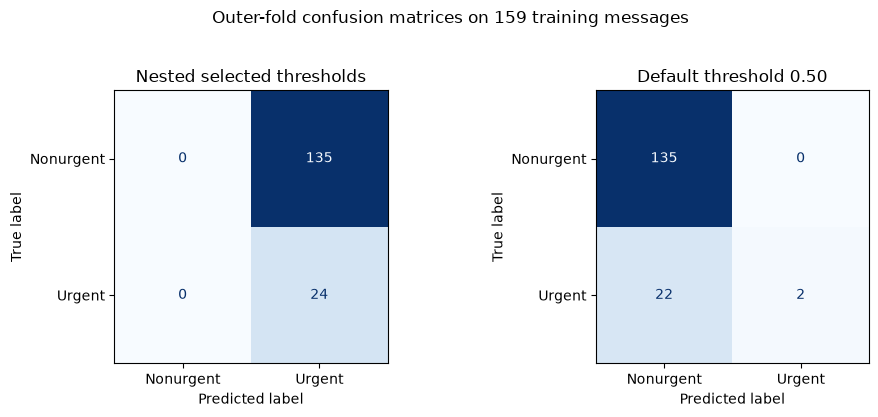

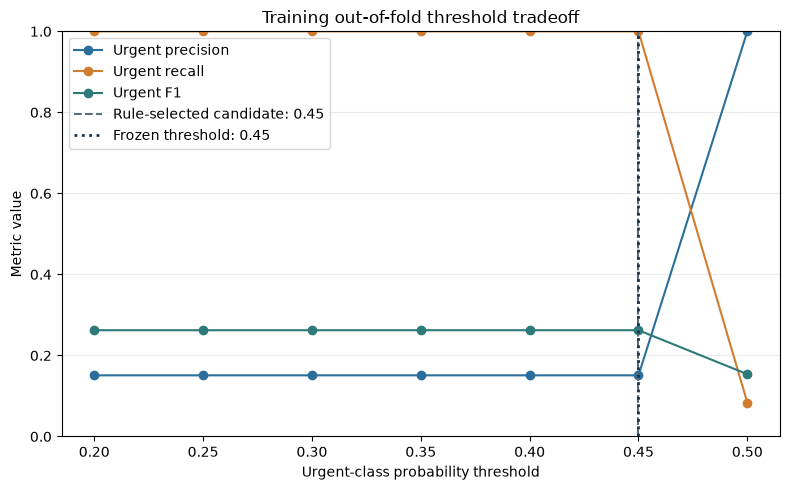

Saved: results/figures/week6_confusion_matrices.png
Saved: results/figures/week6_threshold_tradeoff.png


In [11]:
# I use consistent class ordering, scales, and labels so the tradeoffs remain visible.
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
for axis, (strategy, prediction_column) in zip(
    axes,
    strategy_prediction_columns.items(),
):
    ConfusionMatrixDisplay.from_predictions(
        outer_predictions["true_label"],
        outer_predictions[prediction_column],
        labels=LABEL_ORDER,
        display_labels=["Nonurgent", "Urgent"],
        cmap="Blues",
        colorbar=False,
        ax=axis,
    )
    title = (
        "Nested selected thresholds"
        if strategy == "nested_selected_threshold"
        else "Default threshold 0.50"
    )
    axis.set_title(title)
figure.suptitle("Outer-fold confusion matrices on 159 training messages", y=1.03)
figure.tight_layout()
confusion_path = FIGURES_DIR / "week6_confusion_matrices.png"
figure.savefig(confusion_path, dpi=200, bbox_inches="tight")
display(figure)
plt.close(figure)

figure, axis = plt.subplots(figsize=(8, 5))
for metric, label, color in (
    ("urgent_precision", "Urgent precision", "#2C6E9B"),
    ("urgent_recall", "Urgent recall", "#D17C2F"),
    ("urgent_f1", "Urgent F1", "#2D7A78"),
):
    axis.plot(
        full_training_threshold_table["threshold"],
        full_training_threshold_table[metric],
        marker="o",
        label=label,
        color=color,
    )
axis.axvline(
    candidate_final_threshold,
    color="#5C6B75",
    linestyle="--",
    label=f"Rule-selected candidate: {candidate_final_threshold:.2f}",
)
axis.axvline(
    frozen_final_threshold,
    color="#17324D",
    linestyle=":",
    linewidth=2,
    label=f"Frozen threshold: {frozen_final_threshold:.2f}",
)
axis.set_title("Training out-of-fold threshold tradeoff")
axis.set_xlabel("Urgent-class probability threshold")
axis.set_ylabel("Metric value")
axis.set_xticks(THRESHOLDS)
axis.set_ylim(0.0, 1.0)
axis.grid(axis="y", alpha=0.25)
axis.legend(loc="best")
figure.tight_layout()
threshold_figure_path = FIGURES_DIR / "week6_threshold_tradeoff.png"
figure.savefig(threshold_figure_path, dpi=200, bbox_inches="tight")
display(figure)
plt.close(figure)

print("Saved:", confusion_path.relative_to(PROJECT_ROOT))
print("Saved:", threshold_figure_path.relative_to(PROJECT_ROOT))

### Record reproducibility metadata

The JSON record preserves the frozen configuration, split fingerprints, selection rules, environment, artifact hashes, and holdout status needed to audit this run without exposing email content.

In [12]:
# Artifact hashes bind the reported results to the files produced by this clean run.
def sha256_file(path):
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


artifact_paths = [
    METRICS_DIR / "week6_outer_fold_metrics.csv",
    METRICS_DIR / "week6_outer_predictions.csv",
    METRICS_DIR / "week6_cv_summary.csv",
    METRICS_DIR / "week6_threshold_analysis.csv",
    FIGURES_DIR / "week6_confusion_matrices.png",
    FIGURES_DIR / "week6_threshold_tradeoff.png",
]
artifact_hashes = {
    str(path.relative_to(PROJECT_ROOT)): sha256_file(path)
    for path in artifact_paths
}

training_membership_hash = hashlib.sha256(
    "\n".join(sorted(modeling_data.loc[X_train.index, "message_id"])).encode("utf-8")
).hexdigest()
holdout_membership_hash = hashlib.sha256(
    "\n".join(sorted(modeling_data.loc[X_holdout.index, "message_id"])).encode("utf-8")
).hexdigest()

reproducibility_record = {
    "checkpoint": "week6_nested_cv_threshold_testing",
    "recorded_at_utc": datetime.now(timezone.utc).isoformat(),
    "environment": {
        "python": sys.version.split()[0],
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit_learn": sklearn.__version__,
    },
    "inputs": {
        "raw_data_path": str(RAW_DATA.relative_to(PROJECT_ROOT)),
        "raw_data_bytes": RAW_DATA.stat().st_size,
        "label_manifest_path": str(LABEL_MANIFEST.relative_to(PROJECT_ROOT)),
        "label_manifest_sha256": label_manifest_sha256,
        "reviewed_records": EXPECTED_RECORDS,
        "training_records": EXPECTED_TRAIN_RECORDS,
        "preliminary_holdout_records": EXPECTED_HOLDOUT_RECORDS,
        "training_membership_sha256": training_membership_hash,
        "holdout_membership_sha256": holdout_membership_hash,
    },
    "frozen_candidate": {
        key: value if isinstance(value, (str, int, float, bool)) else repr(value)
        for key, value in expected_parameters.items()
    },
    "validation": {
        "seed": SEED,
        "outer_folds": OUTER_FOLDS,
        "inner_folds": INNER_FOLDS,
        "thresholds": list(THRESHOLDS),
        "selection_rule": [
            "highest urgent F1",
            "higher urgent recall",
            "fewer false positives",
            "higher threshold if still tied",
        ],
        "reliability_rule": (
            "adopt a lower threshold only when aggregate outer-CV urgent recall "
            "improves and urgent F1 does not decrease"
        ),
    },
    "checkpoint_2_results": {
        "reliability_rule_passed": reliability_rule_passed,
        "candidate_final_threshold": candidate_final_threshold,
        "frozen_final_threshold": frozen_final_threshold,
        "holdout_status": "sealed_not_scored",
    },
    "artifact_sha256": artifact_hashes,
}

reproducibility_path = METRICS_DIR / "week6_reproducibility.json"
reproducibility_path.write_text(
    json.dumps(reproducibility_record, indent=2, sort_keys=True) + "\n",
    encoding="utf-8",
)

artifact_inventory = pd.DataFrame(
    [
        {
            "artifact": path,
            "sha256": digest,
        }
        for path, digest in artifact_hashes.items()
    ]
)
display(artifact_inventory)
print("Saved:", reproducibility_path.relative_to(PROJECT_ROOT))

,artifact,sha256
0,results/metrics/week6_outer_fold_metrics.csv,762b3784a7945076a0ee299b2b22cabd0bb5e857727d94...
1,results/metrics/week6_outer_predictions.csv,90677292b414327fa08c51a72c6cd4c48f32378a09a869...
2,results/metrics/week6_cv_summary.csv,036d081a4e0e4d4bec8de3058f6f2cd8eec504506b8abd...
3,results/metrics/week6_threshold_analysis.csv,7cf43e25f216b09cecd21c7064909c6a24c4c016e436c5...
4,results/figures/week6_confusion_matrices.png,975ef6be9f251470aba0fea5fc26754ff27c74cff9ba61...
5,results/figures/week6_threshold_tradeoff.png,df93602ec304275331e453bf76d08d6bd6293f0fa072d6...


Saved: results/metrics/week6_reproducibility.json


### Checkpoint 2 findings

- Every outer fold selected `0.45`; the deterministic higher-threshold tie rule rejected the equivalent lower thresholds from `0.20` through `0.40`.
- Across the concatenated outer validation predictions, `0.45` found all 24 urgent messages and missed none. The default `0.50` threshold found 2 and missed 22.
- The recall improvement came at a severe cost: `0.45` marked all 135 nonurgent messages urgent. Urgent precision was therefore 15.1%, and the false-positive review burden was 135 messages.
- Urgent F1 improved from 0.154 at `0.50` to 0.262 at `0.45`. This satisfies the preregistered reliability rule, but the confusion matrix shows that the improvement is driven by an all-urgent decision boundary rather than useful class separation.
- The full-training out-of-fold analysis also selected `0.45`, so that threshold is frozen for the later holdout comparison. Freezing the threshold preserves the experiment; it is not an endorsement for deployment.
- The probability distribution near the two tested decision regimes indicates a calibration or feature-separation problem in the frozen candidate. The next debugging step should examine privacy-safe false-positive categories and probability ranges before the sealed holdout is scored.

## Takeaways

The nested test did its job: it prevented a favorable recall number from being mistaken for a useful classifier. The lower threshold passed the narrow rule that was registered before the run, but it did so by sending every message to urgent review. That behavior would overwhelm a user and cannot support autonomous routing. I will carry `0.45` forward only as the locked experimental comparison, then document the false-positive patterns and any code-level debugging findings without changing the frozen candidate. The preliminary holdout remains sealed until those training-data steps and artifacts are complete.